In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sushantkr878/binary-classification-test-data/Binary Classification TEST.csv
/kaggle/input/datasets/sushantkr878/binary-classification-train-data/Binary_Classification_train.csv


In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sushantkr878/binary-classification-test-data/Binary Classification TEST.csv
/kaggle/input/datasets/sushantkr878/binary-classification-train-data/Binary_Classification_train.csv


In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/kaggle/input/datasets/sushantkr878/binary-classification-train-data/Binary_Classification_train.csv')

In [5]:
df.head()

,id,Mean_Integrated,SD,EK,Skewness,Mean_DMSNR_Curve,SD_DMSNR_Curve,EK_DMSNR_Curve,Skewness_DMSNR_Curve,Class
0,0,133.171875,59.716081,0.043133,-0.703383,54.917224,70.084438,0.749798,-0.649512,0
1,1,87.093750,36.257973,0.435469,2.266057,3.417224,21.865069,7.039330,52.686251,0
2,2,112.640625,39.818393,0.379639,0.922306,2.730769,15.689690,8.193471,85.649785,0
3,3,120.679688,45.918448,-0.098490,0.011775,2.696488,20.954662,8.183874,70.332899,0
4,4,134.070312,57.720107,-0.107772,-0.573335,1.107860,11.255051,16.107748,308.753765,0


In [6]:
df.shape

(117564, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117564 entries, 0 to 117563
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    117564 non-null  int64  
 1   Mean_Integrated       117564 non-null  float64
 2   SD                    117564 non-null  float64
 3   EK                    117564 non-null  float64
 4   Skewness              117564 non-null  float64
 5   Mean_DMSNR_Curve      117564 non-null  float64
 6   SD_DMSNR_Curve        117564 non-null  float64
 7   EK_DMSNR_Curve        117564 non-null  float64
 8   Skewness_DMSNR_Curve  117564 non-null  float64
 9   Class                 117564 non-null  int64  
dtypes: float64(8), int64(2)
memory usage: 9.0 MB


In [8]:
# Target variable is Class

In [9]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94051 entries, 100151 to 15795
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    94051 non-null  int64  
 1   Mean_Integrated       94051 non-null  float64
 2   SD                    94051 non-null  float64
 3   EK                    94051 non-null  float64
 4   Skewness              94051 non-null  float64
 5   Mean_DMSNR_Curve      94051 non-null  float64
 6   SD_DMSNR_Curve        94051 non-null  float64
 7   EK_DMSNR_Curve        94051 non-null  float64
 8   Skewness_DMSNR_Curve  94051 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 7.2 MB


In [12]:
X_train = X_train.drop(columns=['id']) 
X_test = X_test.drop(columns=['id'])

In [13]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94051 entries, 100151 to 15795
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Mean_Integrated       94051 non-null  float64
 1   SD                    94051 non-null  float64
 2   EK                    94051 non-null  float64
 3   Skewness              94051 non-null  float64
 4   Mean_DMSNR_Curve      94051 non-null  float64
 5   SD_DMSNR_Curve        94051 non-null  float64
 6   EK_DMSNR_Curve        94051 non-null  float64
 7   Skewness_DMSNR_Curve  94051 non-null  float64
dtypes: float64(8)
memory usage: 6.5 MB


In [14]:
X_train['Mean_Integrated'].skew()

np.float64(-1.8413252252827024)

<Axes: ylabel='Density'>

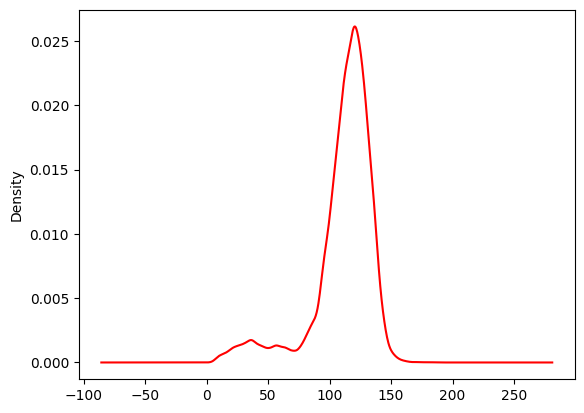

In [15]:
X_train['Mean_Integrated'].plot(kind='kde', color='red')

<Axes: xlabel='Mean_Integrated'>

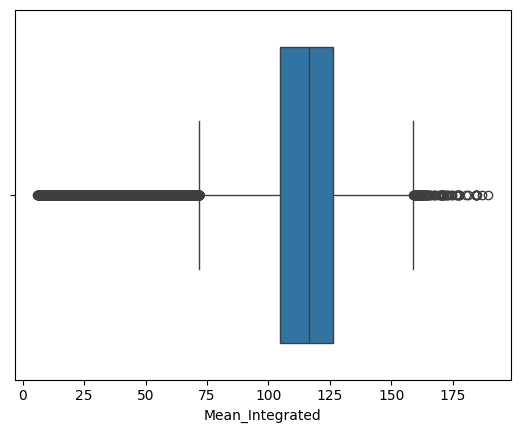

In [16]:
sns.boxplot(x=X_train['Mean_Integrated'])

<Axes: xlabel='Mean_Integrated', ylabel='Count'>

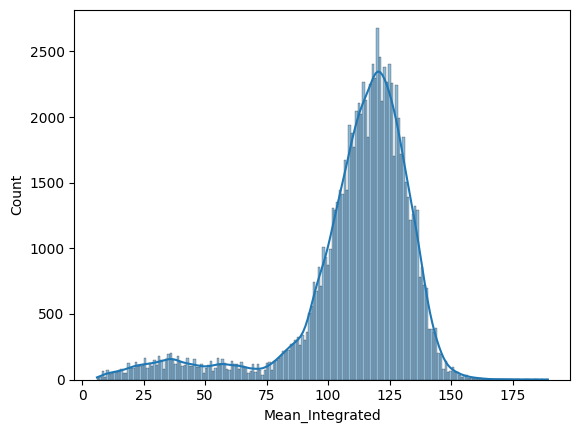

In [17]:
sns.histplot(data=X_train, x='Mean_Integrated', kde=True)

In [18]:
from scipy import stats

In [19]:
# ── IQR Method ────────────────────────────────────────────────────
Q1 = X_train['Mean_Integrated'].quantile(0.25)
Q3 = X_train['Mean_Integrated'].quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

X_train_iqr_MI = X_train[
    (X_train['Mean_Integrated'] >= lower_iqr) &
    (X_train['Mean_Integrated'] <= upper_iqr)
].copy()


In [20]:
X_train_iqr_MI['Mean_Integrated'].skew()  # np.float64(-1.8413252252827024)

np.float64(-0.3545060487553666)

/tmp/ipykernel_16/3764667525.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


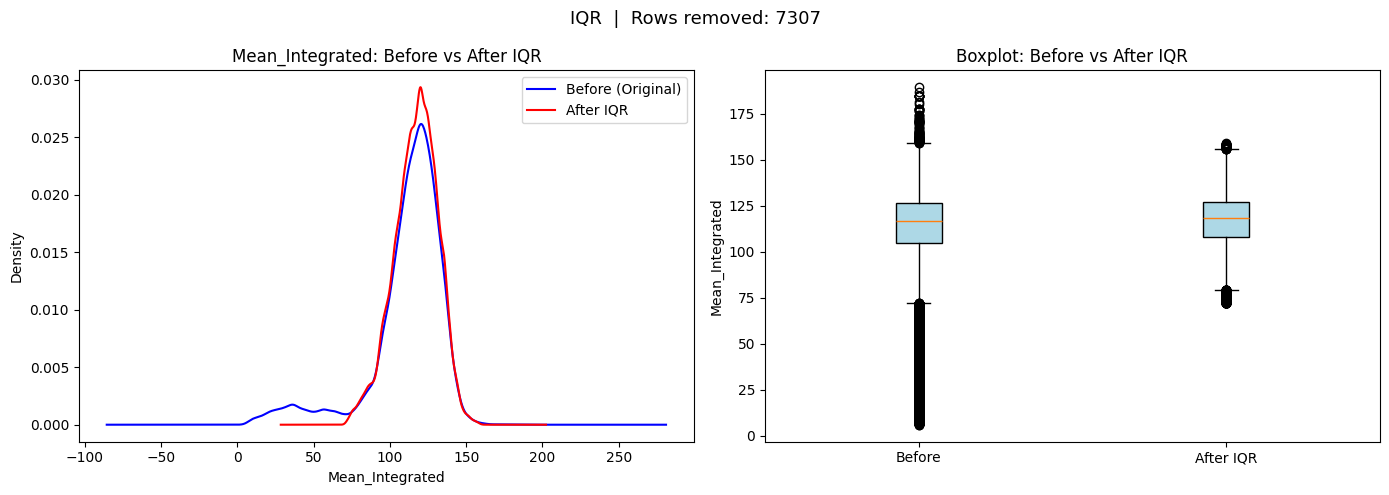

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Before vs After on same plot (left) ───────────────────────────
X_train['Mean_Integrated'].plot(kind='kde', ax=axes[0], color='blue', label='Before (Original)')
X_train_iqr_MI['Mean_Integrated'].plot(kind='kde', ax=axes[0], color='red', label='After IQR')

axes[0].set_title('Mean_Integrated: Before vs After IQR')
axes[0].set_xlabel('Mean_Integrated')
axes[0].set_ylabel('Density')
lines, labels = axes[0].get_legend_handles_labels()
axes[0].legend(lines, labels, loc='best')

# ── Boxplot to see outlier removal (right) ────────────────────────
axes[1].boxplot(
    [X_train['Mean_Integrated'], X_train_iqr_MI['Mean_Integrated']],
    labels=['Before', 'After IQR'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
axes[1].set_title('Boxplot: Before vs After IQR')
axes[1].set_ylabel('Mean_Integrated')

plt.suptitle(f"IQR  |  Rows removed: {len(X_train) - len(X_train_iqr_MI)}", fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# SD
X_train['SD'].skew()

np.float64(-0.5220480755651854)

<Axes: ylabel='Density'>

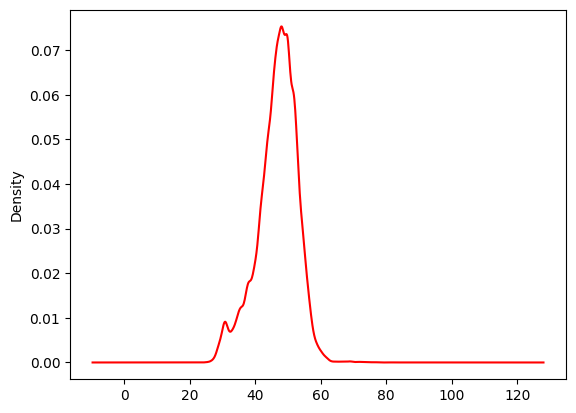

In [23]:
X_train['SD'].plot(kind='kde', color='red')

<Axes: xlabel='SD'>

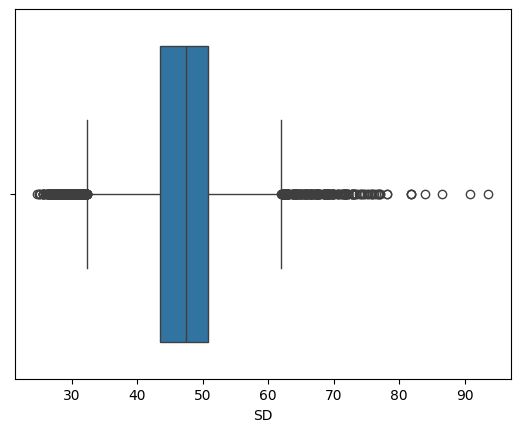

In [24]:
sns.boxplot(x=X_train['SD'])

In [25]:
# ── IQR Method ────────────────────────────────────────────────────
Q1 = X_train['Mean_Integrated'].quantile(0.25)
Q3 = X_train['Mean_Integrated'].quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

X_train_iqr_SD = X_train[
    (X_train['Mean_Integrated'] >= lower_iqr) &
    (X_train['Mean_Integrated'] <= upper_iqr)
].copy()

In [26]:
X_train_iqr_SD['SD'].skew()

np.float64(-0.06778498561961728)

/tmp/ipykernel_16/1469091194.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


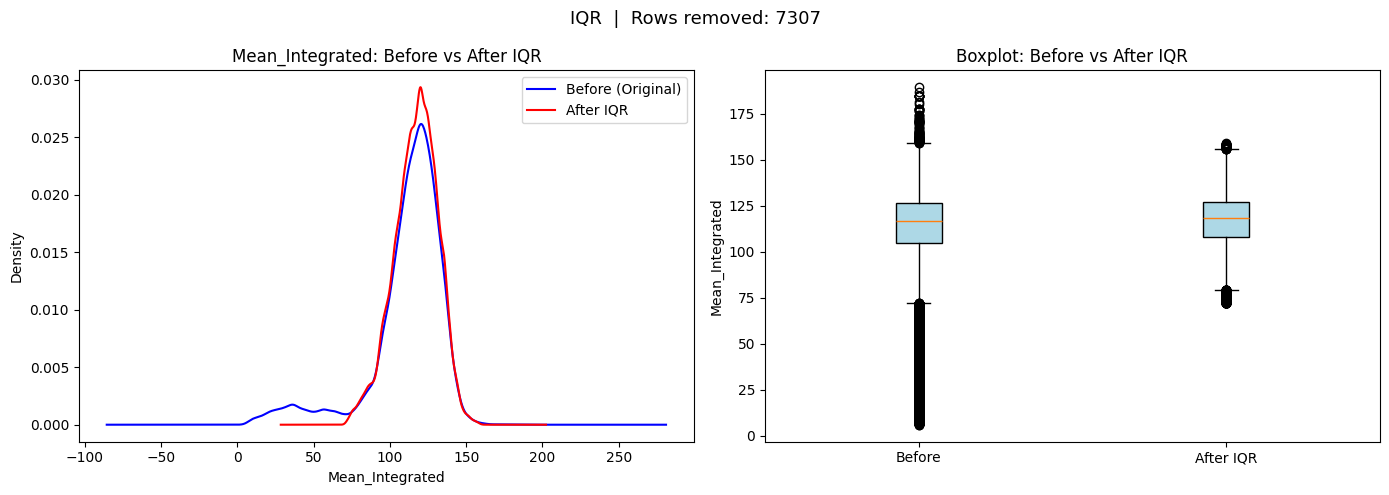

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Before vs After on same plot (left) ───────────────────────────
X_train['Mean_Integrated'].plot(kind='kde', ax=axes[0], color='blue', label='Before (Original)')
X_train_iqr_SD['Mean_Integrated'].plot(kind='kde', ax=axes[0], color='red', label='After IQR')

axes[0].set_title('Mean_Integrated: Before vs After IQR')
axes[0].set_xlabel('Mean_Integrated')
axes[0].set_ylabel('Density')
lines, labels = axes[0].get_legend_handles_labels()
axes[0].legend(lines, labels, loc='best')

# ── Boxplot to see outlier removal (right) ────────────────────────
axes[1].boxplot(
    [X_train['Mean_Integrated'], X_train_iqr_SD['Mean_Integrated']],
    labels=['Before', 'After IQR'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
axes[1].set_title('Boxplot: Before vs After IQR')
axes[1].set_ylabel('Mean_Integrated')

plt.suptitle(f"IQR  |  Rows removed: {len(X_train) - len(X_train_iqr_SD)}", fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
# EK
X_train['EK'].skew()

np.float64(3.4327646863106174)

In [29]:
# ── IQR Method ────────────────────────────────────────────────────
Q1 = X_train['EK'].quantile(0.25)
Q3 = X_train['EK'].quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

X_train_iqr_EK = X_train[
    (X_train['EK'] >= lower_iqr) &
    (X_train['EK'] <= upper_iqr)
].copy()


In [30]:
X_train_iqr_EK['EK'].skew()

np.float64(0.39920984498858514)

/tmp/ipykernel_16/2709960904.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


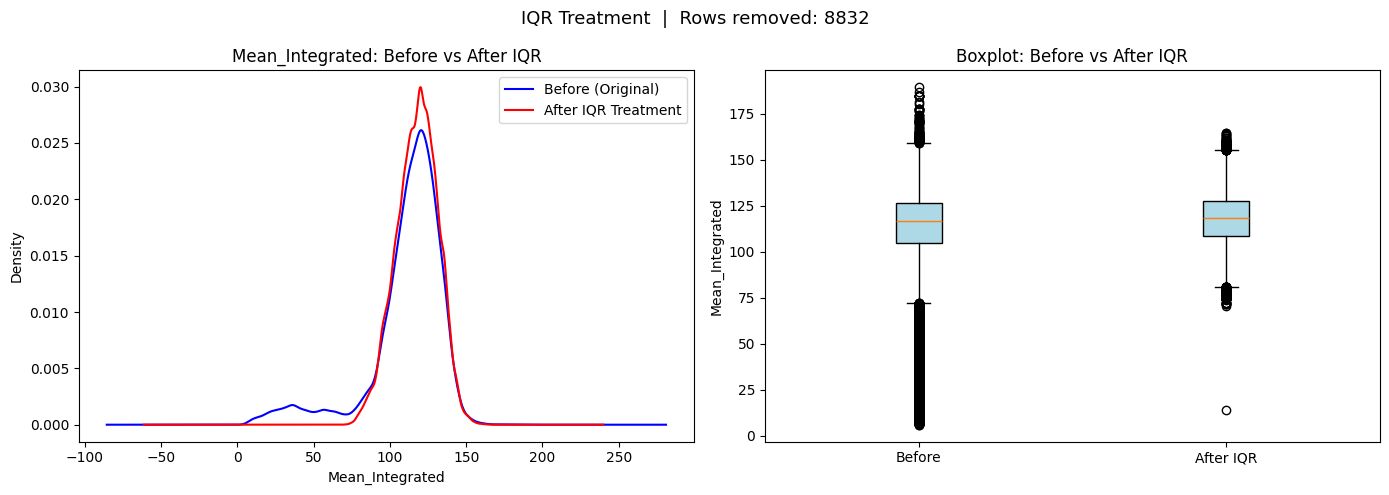

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Before vs After on same plot (left) ───────────────────────────
X_train['Mean_Integrated'].plot(kind='kde', ax=axes[0], color='blue', label='Before (Original)')
X_train_iqr_EK['Mean_Integrated'].plot(kind='kde', ax=axes[0], color='red', label='After IQR Treatment')

axes[0].set_title('Mean_Integrated: Before vs After IQR')
axes[0].set_xlabel('Mean_Integrated')
axes[0].set_ylabel('Density')
lines, labels = axes[0].get_legend_handles_labels()
axes[0].legend(lines, labels, loc='best')

# ── Boxplot to see outlier removal (right) ────────────────────────
axes[1].boxplot(
    [X_train['Mean_Integrated'], X_train_iqr_EK['Mean_Integrated']],
    labels=['Before', 'After IQR'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
axes[1].set_title('Boxplot: Before vs After IQR')
axes[1].set_ylabel('Mean_Integrated')

plt.suptitle(f"IQR Treatment  |  Rows removed: {len(X_train) - len(X_train_iqr_EK)}", fontsize=13)
plt.tight_layout()
plt.show()

In [32]:
# Skewness 
X_train['Skewness'].skew()

np.float64(4.38107619074877)

In [33]:
# ── IQR Method ────────────────────────────────────────────────────
Q1 = X_train['Skewness'].quantile(0.25)
Q3 = X_train['Skewness'].quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

X_train_iqr_skewness = X_train[
    (X_train['Skewness'] >= lower_iqr) &
    (X_train['Skewness'] <= upper_iqr)
].copy()


In [34]:
X_train_iqr_skewness['Skewness'].skew()

np.float64(1.0400836778619489)

/tmp/ipykernel_16/1203383919.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


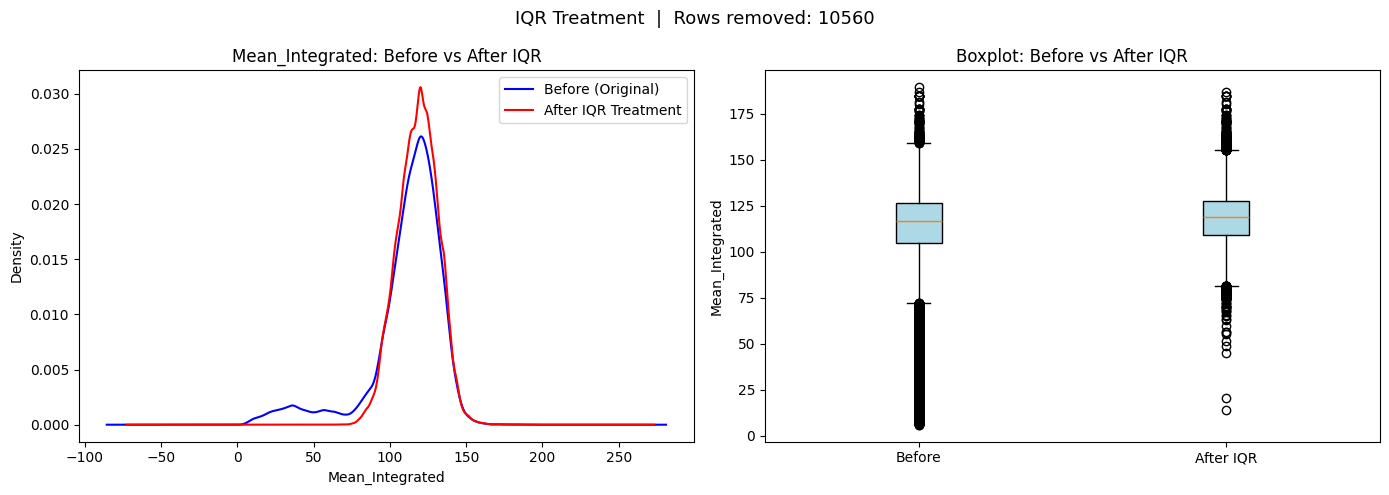

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Before vs After on same plot (left) ───────────────────────────
X_train['Mean_Integrated'].plot(kind='kde', ax=axes[0], color='blue', label='Before (Original)')
X_train_iqr_skewness['Mean_Integrated'].plot(kind='kde', ax=axes[0], color='red', label='After IQR Treatment')

axes[0].set_title('Mean_Integrated: Before vs After IQR')
axes[0].set_xlabel('Mean_Integrated')
axes[0].set_ylabel('Density')
lines, labels = axes[0].get_legend_handles_labels()
axes[0].legend(lines, labels, loc='best')

# ── Boxplot to see outlier removal (right) ────────────────────────
axes[1].boxplot(
    [X_train['Mean_Integrated'], X_train_iqr_skewness['Mean_Integrated']],
    labels=['Before', 'After IQR'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
axes[1].set_title('Boxplot: Before vs After IQR')
axes[1].set_ylabel('Mean_Integrated')

plt.suptitle(f"IQR Treatment  |  Rows removed: {len(X_train) - len(X_train_iqr_skewness)}", fontsize=13)
plt.tight_layout()
plt.show()

In [36]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94051 entries, 100151 to 15795
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Mean_Integrated       94051 non-null  float64
 1   SD                    94051 non-null  float64
 2   EK                    94051 non-null  float64
 3   Skewness              94051 non-null  float64
 4   Mean_DMSNR_Curve      94051 non-null  float64
 5   SD_DMSNR_Curve        94051 non-null  float64
 6   EK_DMSNR_Curve        94051 non-null  float64
 7   Skewness_DMSNR_Curve  94051 non-null  float64
dtypes: float64(8)
memory usage: 6.5 MB


In [37]:
#Mean_DMSNR_Curve
X_train['Mean_DMSNR_Curve'].skew()

np.float64(3.4283525584496166)

<Axes: ylabel='Density'>

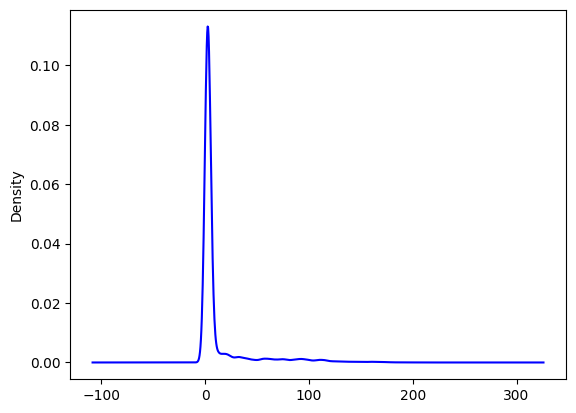

In [38]:
X_train['Mean_DMSNR_Curve'].plot(kind='kde', color='blue')

In [39]:
X_train_log_MDC = X_train.copy()
X_train_log_MDC['Mean_DMSNR_Curve'] = np.log1p(X_train['Mean_DMSNR_Curve'])

In [40]:
X_train_log_MDC['Mean_DMSNR_Curve'].skew()

np.float64(1.8599966467723674)

/tmp/ipykernel_16/2943264292.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


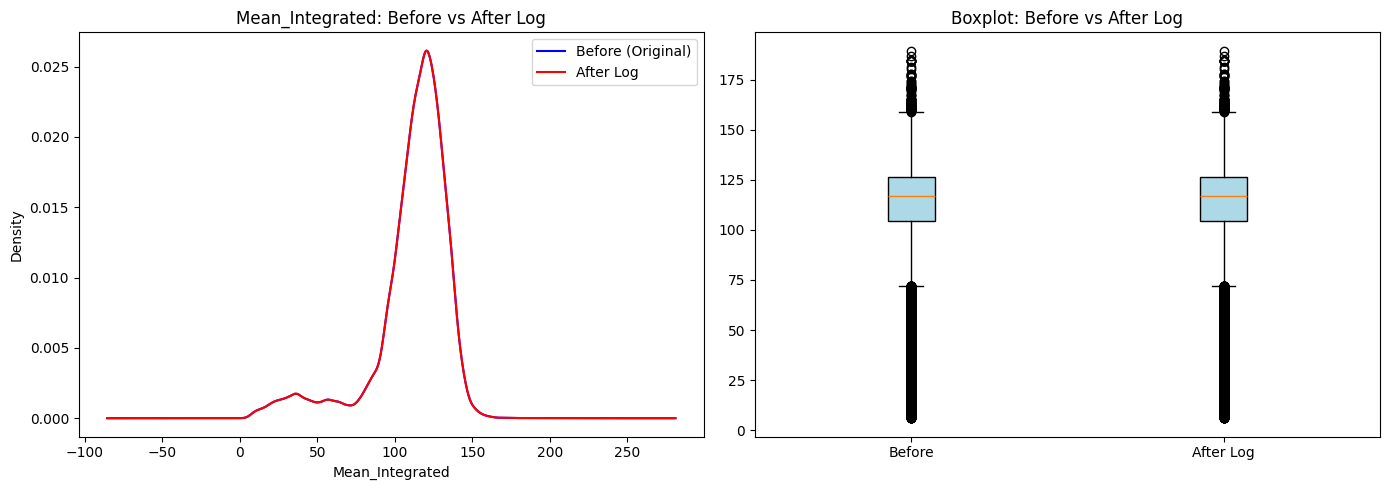

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Before vs After on same plot (left) ───────────────────────────
X_train['Mean_Integrated'].plot(kind='kde', ax=axes[0], color='blue', label='Before (Original)')
X_train_log_MDC['Mean_Integrated'].plot(kind='kde', ax=axes[0], color='red', label='After Log')

axes[0].set_title('Mean_Integrated: Before vs After Log')
axes[0].set_xlabel('Mean_Integrated')
axes[0].set_ylabel('Density')
lines, labels = axes[0].get_legend_handles_labels()
axes[0].legend(lines, labels, loc='best')

# ── Boxplot to see outlier removal (right) ────────────────────────
axes[1].boxplot(
    [X_train['Mean_Integrated'], X_train_log_MDC['Mean_Integrated']],
    labels=['Before', 'After Log'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
axes[1].set_title('Boxplot: Before vs After Log')

plt.tight_layout()
plt.show()

In [42]:
# SD_DMSNR_Curve 

X_train['SD_DMSNR_Curve'].skew()

np.float64(2.0105839729531825)

In [43]:
X_train_log_SD_DMSNR_Curve = X_train.copy()
X_train_log_SD_DMSNR_Curve['SD_DMSNR_Curve'] = np.log1p(X_train['SD_DMSNR_Curve'])

In [44]:
X_train['SD_DMSNR_Curve'].skew()

np.float64(2.0105839729531825)

In [45]:
#EK_DMSNR_Curve 
X_train['EK_DMSNR_Curve'].skew()

np.float64(-0.042345683041635884)

In [46]:
# Skewness_DMSNR_Curve
X_train['Skewness_DMSNR_Curve'].skew()

np.float64(2.3724928123962448)

In [47]:
z_scores = np.abs(stats.zscore(X_train['Skewness_DMSNR_Curve']))
X_train_zscore_skewcurve = X_train[z_scores < 3].copy() 


In [48]:
X_train_zscore_skewcurve['Skewness_DMSNR_Curve'].skew()

np.float64(0.8289042574652382)

/tmp/ipykernel_16/1489936683.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


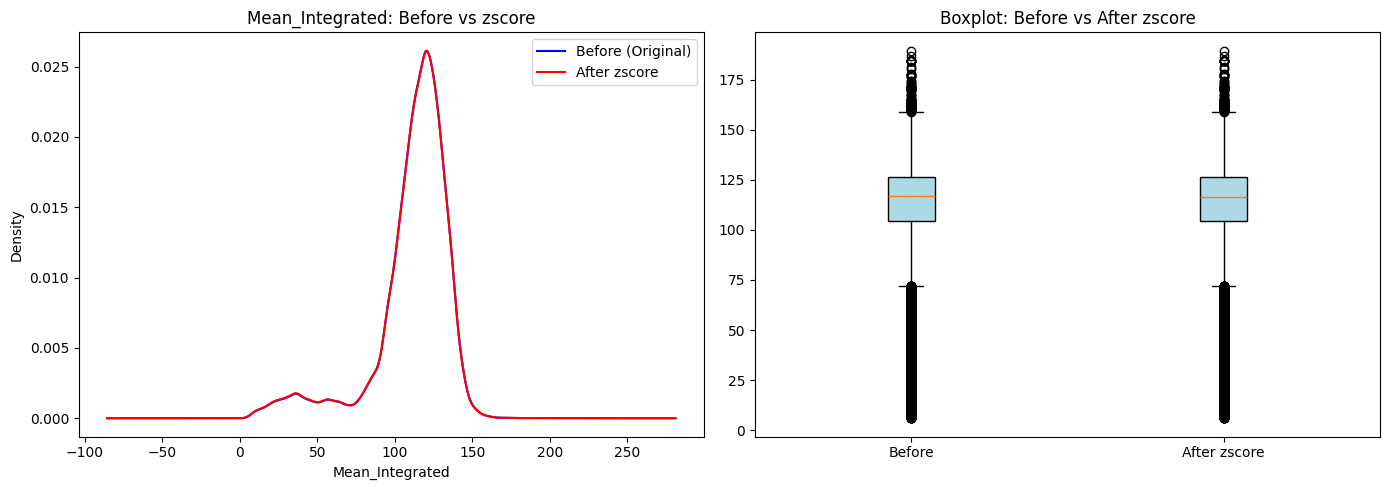

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Before vs After on same plot (left) ───────────────────────────
X_train['Mean_Integrated'].plot(kind='kde', ax=axes[0], color='blue', label='Before (Original)')
X_train_zscore_skewcurve['Mean_Integrated'].plot(kind='kde', ax=axes[0], color='red', label='After zscore')

axes[0].set_title('Mean_Integrated: Before vs zscore')
axes[0].set_xlabel('Mean_Integrated')
axes[0].set_ylabel('Density')
lines, labels = axes[0].get_legend_handles_labels()
axes[0].legend(lines, labels, loc='best')

# ── Boxplot to see outlier removal (right) ────────────────────────
axes[1].boxplot(
    [X_train['Mean_Integrated'], X_train_zscore_skewcurve['Mean_Integrated']],
    labels=['Before', 'After zscore'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
axes[1].set_title('Boxplot: Before vs After zscore')

plt.tight_layout()
plt.show()

In [50]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94051 entries, 100151 to 15795
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Mean_Integrated       94051 non-null  float64
 1   SD                    94051 non-null  float64
 2   EK                    94051 non-null  float64
 3   Skewness              94051 non-null  float64
 4   Mean_DMSNR_Curve      94051 non-null  float64
 5   SD_DMSNR_Curve        94051 non-null  float64
 6   EK_DMSNR_Curve        94051 non-null  float64
 7   Skewness_DMSNR_Curve  94051 non-null  float64
dtypes: float64(8)
memory usage: 6.5 MB


In [51]:
# Reset X_train to original (before any treatment)
# Then apply winsorization to all columns at once

cols_to_treat = ['Mean_Integrated', 'SD', 'EK', 'Skewness', 
                 'Mean_DMSNR_Curve', 'SD_DMSNR_Curve', 
                 'EK_DMSNR_Curve', 'Skewness_DMSNR_Curve']

for col in cols_to_treat:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)  # train bounds on test!

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94051 entries, 100151 to 15795
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Mean_Integrated       94051 non-null  float64
 1   SD                    94051 non-null  float64
 2   EK                    94051 non-null  float64
 3   Skewness              94051 non-null  float64
 4   Mean_DMSNR_Curve      94051 non-null  float64
 5   SD_DMSNR_Curve        94051 non-null  float64
 6   EK_DMSNR_Curve        94051 non-null  float64
 7   Skewness_DMSNR_Curve  94051 non-null  float64
dtypes: float64(8)
memory usage: 6.5 MB


In [52]:
X_train['Mean_DMSNR_Curve']    = np.log1p(X_train['Mean_DMSNR_Curve'])
X_train['SD_DMSNR_Curve']      = np.log1p(X_train['SD_DMSNR_Curve'])
X_test['Mean_DMSNR_Curve']     = np.log1p(X_test['Mean_DMSNR_Curve'])
X_test['SD_DMSNR_Curve']       = np.log1p(X_test['SD_DMSNR_Curve'])
# then run the winsorization loop above

In [53]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94051 entries, 100151 to 15795
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Mean_Integrated       94051 non-null  float64
 1   SD                    94051 non-null  float64
 2   EK                    94051 non-null  float64
 3   Skewness              94051 non-null  float64
 4   Mean_DMSNR_Curve      94051 non-null  float64
 5   SD_DMSNR_Curve        94051 non-null  float64
 6   EK_DMSNR_Curve        94051 non-null  float64
 7   Skewness_DMSNR_Curve  94051 non-null  float64
dtypes: float64(8)
memory usage: 6.5 MB


# Model

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score, classification_report

In [55]:
# ── Step 1: Train Model ───────────────────────────────────────────
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [56]:
# ── Step 2: Get Probabilities (needed for log loss) ───────────────
y_train_prob = model.predict_proba(X_train)
y_test_prob  = model.predict_proba(X_test)

In [57]:
# ── Step 3: Get Predictions (needed for accuracy) ─────────────────
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

In [58]:
train_logloss = log_loss(y_train, y_train)
test_logloss  = log_loss(y_test, y_test)

In [59]:
print(f"Train Log Loss : {train_logloss:.4f}")
print(f"Test  Log Loss : {test_logloss:.4f}")

Train Log Loss : 0.0000
Test  Log Loss : 0.0000


In [60]:
# ── Step 5: Accuracy ──────────────────────────────────────────────
print(f"\nTrain Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test  Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")


Train Accuracy : 0.9891
Test  Accuracy : 0.9894


In [61]:
print("\nClassification Report:")
print(classification_report(y_test, y_test))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21318
           1       1.00      1.00      1.00      2195

    accuracy                           1.00     23513
   macro avg       1.00      1.00      1.00     23513
weighted avg       1.00      1.00      1.00     23513



# TEST DATA

In [62]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sushantkr878/binary-classification-test-data/Binary Classification TEST.csv
/kaggle/input/datasets/sushantkr878/binary-classification-train-data/Binary_Classification_train.csv


In [63]:
test = pd.read_csv('/kaggle/input/datasets/sushantkr878/binary-classification-test-data/Binary Classification TEST.csv')

In [64]:
test.head()

,id,Mean_Integrated,SD,EK,Skewness,Mean_DMSNR_Curve,SD_DMSNR_Curve,EK_DMSNR_Curve,Skewness_DMSNR_Curve
0,117564,140.046875,54.507800,0.058862,-0.567263,2.337793,14.868335,9.591760,117.988781
1,117565,107.828125,51.578965,0.284368,-0.338430,1.574415,12.501437,11.694968,182.704822
2,117566,135.062500,49.812343,-0.087784,-0.094341,3.576923,21.243336,7.252386,59.021499
3,117567,112.812500,41.926647,0.519921,1.287762,6.669732,29.013153,5.097661,27.105240
4,117568,96.210938,35.322620,0.481286,2.443080,2.218227,17.041064,9.766006,117.131775


In [65]:
test_ids = test['id']

In [66]:
test = test.drop(columns=['id'])

In [67]:
test['Mean_DMSNR_Curve'] = np.log1p(test['Mean_DMSNR_Curve'])
test['SD_DMSNR_Curve']   = np.log1p(test['SD_DMSNR_Curve'])

In [68]:
cols_to_treat = ['Mean_Integrated', 'SD', 'EK', 'Skewness',
                 'Mean_DMSNR_Curve', 'SD_DMSNR_Curve',
                 'EK_DMSNR_Curve', 'Skewness_DMSNR_Curve']

In [69]:
for col in cols_to_treat:
    lower = X_train[col].quantile(0.01)   
    upper = X_train[col].quantile(0.99)
    test[col] = test[col].clip(lower, upper)

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X_train.columns)

In [71]:
test_scaled = scaler.transform(test)   
test_scaled = pd.DataFrame(test_scaled, columns=test.columns)

In [72]:
test_prob = model.predict_proba(test_scaled)[:, 1] 

In [73]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [74]:
submission = pd.DataFrame({
    'id'    : test_ids,
    'target': test_prob
})

In [75]:
submission.to_csv('submission.csv', index=False)
print(submission.head())
print(f"\nSubmission shape: {submission.shape}")

       id    target
0  117564  0.023068
1  117565  0.036913
2  117566  0.055552
3  117567  0.765735
4  117568  0.308630

Submission shape: (78377, 2)
